# Decision Trees and Randrom Forests - Machine Learning with Python

The following topics are covered in this tutorial
* Downloading a real-world DataclassInstance
* Preparing a dataset for training.
* Training and interpreting decision trees.
* Training and interpreting Random forest.
* Overfitting, hyperparameter tuning and regularization.
* Making predictions on single inputs

In [1]:
import requests, zipfile, pathlib
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [2]:
# Set up our dataset path
dataset_path = Path("weather-dataset-rattle-package/")
# dataset_path = data_path / "weather-dataset-rattle-package"

# If dataset path does not exist, make it
if dataset_path.is_dir():
  print(f"{dataset_path} already exists, skipping creation")

else:
  print(f"{dataset_path} does not exist, creating one...")
  dataset_path.mkdir(parents = True, exist_ok = True)

# Download dataset from github
with open(dataset_path / "archive.zip", "wb") as f:
  request = requests.get(("https://github.com/Musawer-Afzal/ML-with-Scikit-Learn-in-Python/raw/refs/heads/master/Datasets/archive.zip"))
  print("Downloading Austrailia Weather Dataset")
  f.write(request.content)

# Unzip the dataset if zip file
with zipfile.ZipFile(dataset_path / "archive.zip", "r") as zip_ref:
  print("Unzipping Weather dataset")
  zip_ref.extractall(dataset_path)

weather-dataset-rattle-package does not exist, creating one...
Unzipping Weather dataset


In [3]:
dataset_dir = '/content/weather-dataset-rattle-package/weatherAUS.csv'
raw_df = pd.read_csv(dataset_dir)

In [4]:
raw_df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,ENE,13.0,11.0,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,N,13.0,9.0,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,WNW,9.0,9.0,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,N,13.0,7.0,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


**Question**: The Rain in Australia dataset contains about 10 years of daily weather observations from numerous Australian weather stations.

As a data scientist at the Bureau of Meterology, you are tasked with creating a fully-automated system that can use today's weather data for a given location to predict whether it will rain at the location tomorrow

In [5]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [6]:
raw_df.dropna(subset = ['RainTomorrow'], inplace = True)

## Preparing the Data for Training

We'll perform the following steps to prepare the dataset for training.

1. Create a train/test/validation split.
2. identify input and target columns.
3. identify numeric and categorical columns.
4. Impute (fill) missing numeric values.
5. Scale numeric values to the (0, 1) range.
6. Encode categirical columns to one-hot vectors

### Training, Validation and Test Sets

<Axes: title={'center': 'No. of Rows per Year'}, xlabel='Date', ylabel='count'>

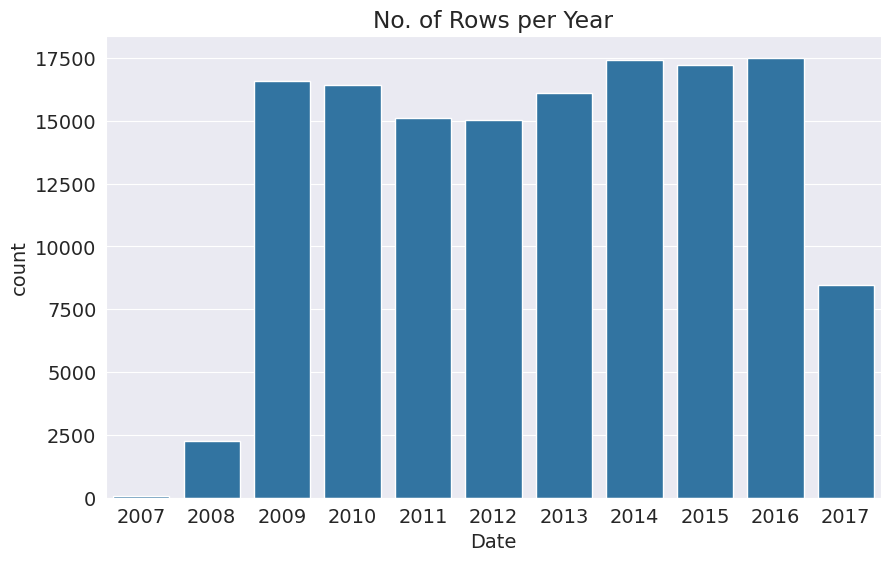

In [7]:
plt.title('No. of Rows per Year')
sns.countplot(x = pd.to_datetime(raw_df.Date).dt.year)

We'll use data till 2014 for the training set, data from 2015 for the validation set, and the data from 2016 and 2017 for the test set

In [8]:
year = pd.to_datetime(raw_df.Date).dt.year

train_df = raw_df[year < 2015]
val_df = raw_df[year == 2015]
test_df = raw_df[year > 2015]

In [9]:
print('train_df: ', train_df.shape)
print('val_df: ', val_df.shape)
print('test_df: ', test_df.shape)

train_df:  (98988, 23)
val_df:  (17231, 23)
test_df:  (25974, 23)


### Input and Target Columns

Let's identify input and target columns

In [10]:
input_cols = list(train_df.columns)[1:-1]
target_cols = 'RainTomorrow'

In [11]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_cols].copy()

In [12]:
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_cols].copy()

In [13]:
test_inputs = test_df[input_cols].copy()
test_targets = test_df[target_cols].copy()

Let's also identify the numeric and categorical columns

In [14]:
numeric_cols = train_inputs.select_dtypes(include = np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

In [15]:
print(numeric_cols)

['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']


In [16]:
train_inputs[numeric_cols].isna().sum().sort_values(ascending = False)

,0
Sunshine,40696
Evaporation,37110
Cloud3pm,36766
Cloud9am,35764
Pressure9am,9345
Pressure3pm,9309
WindGustSpeed,6902
Humidity9am,1265
Humidity3pm,1186
WindSpeed3pm,1140


### Imputing missing numeric values

In [17]:
imputer = SimpleImputer(strategy = 'mean').fit(raw_df[numeric_cols])

In [18]:
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = imputer.transform(test_inputs[numeric_cols])

In [19]:
test_inputs[numeric_cols].isna().sum()

,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustSpeed,0
WindSpeed9am,0
WindSpeed3pm,0
Humidity9am,0
Humidity3pm,0


### Scaling Numeric Features

In [20]:
scaler = MinMaxScaler().fit(raw_df[numeric_cols])

In [21]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

In [22]:
train_inputs.describe().loc[['min', 'max']]

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
min,0.0,0.013233,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0304,0.0,0.0,0.027426,0.005758
max,1.0,1.000000,1.0,0.568276,0.986207,1.0,0.669231,1.0,1.0,1.0,1.0,1.0000,1.0,1.0,1.000000,0.988484


### Encoding Categorical Data

In [23]:
train_inputs[categorical_cols] = train_inputs[categorical_cols].fillna('Unknown')
val_inputs[categorical_cols] = val_inputs[categorical_cols].fillna('Unknown')
test_inputs[categorical_cols] = test_inputs[categorical_cols].fillna('Unknown')

In [24]:
encoder = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore').fit(raw_df[categorical_cols])

In [25]:
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

In [26]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])

/tmp/ipython-input-1584174743.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
/tmp/ipython-input-1584174743.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
/tmp/ipython-input-1584174743.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns 

In [27]:
test_inputs[encoded_cols]

,Location_Adelaide,Location_Albany,Location_Albury,Location_AliceSprings,Location_BadgerysCreek,Location_Ballarat,Location_Bendigo,Location_Brisbane,Location_Cairns,Location_Canberra,Location_Cobar,Location_CoffsHarbour,Location_Dartmoor,Location_Darwin,Location_GoldCoast,Location_Hobart,Location_Katherine,Location_Launceston,Location_Melbourne,Location_MelbourneAirport,Location_Mildura,Location_Moree,Location_MountGambier,Location_MountGinini,Location_Newcastle,Location_Nhil,Location_NorahHead,Location_NorfolkIsland,Location_Nuriootpa,Location_PearceRAAF,Location_Penrith,Location_Perth,Location_PerthAirport,Location_Portland,Location_Richmond,Location_Sale,Location_SalmonGums,Location_Sydney,Location_SydneyAirport,Location_Townsville,Location_Tuggeranong,Location_Uluru,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera,WindGustDir_E,WindGustDir_ENE,WindGustDir_ESE,WindGustDir_N,WindGustDir_NE,WindGustDir_NNE,WindGustDir_NNW,WindGustDir_NW,WindGustDir_S,WindGustDir_SE,WindGustDir_SSE,WindGustDir_SSW,WindGustDir_SW,WindGustDir_W,WindGustDir_WNW,WindGustDir_WSW,WindGustDir_nan,WindDir9am_E,WindDir9am_ENE,WindDir9am_ESE,WindDir9am_N,WindDir9am_NE,WindDir9am_NNE,WindDir9am_NNW,WindDir9am_NW,WindDir9am_S,WindDir9am_SE,WindDir9am_SSE,WindDir9am_SSW,WindDir9am_SW,WindDir9am_W,WindDir9am_WNW,WindDir9am_WSW,WindDir9am_nan,WindDir3pm_E,WindDir3pm_ENE,WindDir3pm_ESE,WindDir3pm_N,WindDir3pm_NE,WindDir3pm_NNE,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes,RainToday_nan
2498,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2499,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2500,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2501,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2502,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [28]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]
X_test = test_inputs[numeric_cols + encoded_cols]

### Training and Visualizing Decision Trees

```
if salary >= $50K and salary <= $80K:
  print(accept_offer)
  if office_near_home == True:
    print(accept_offer)
      if provide_cab_facility == True:
        print(accept_offer)
      else:
      print(reject)
  else:
    print(reject)
else:
  print(decline)
```

A decision tree in ML works the same way, except that we let the computer figure out the optimal structure and hierarchy of decisions, instead of coming up with criteria manually.

### Training

In [29]:
model = DecisionTreeClassifier(random_state = 42)

In [30]:
%%time
model.fit(X_train, train_targets)

CPU times: user 4.65 s, sys: 63.8 ms, total: 4.71 s
Wall time: 6.3 s


DecisionTreeClassifier(random_state=42)

An optimal decision tree has been created using the training data

### Evaluation

In [31]:
train_preds = model.predict(X_train)

In [32]:
train_preds

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

In [33]:
pd.value_counts(train_preds)

/tmp/ipython-input-1258350197.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(train_preds)


,count
No,76707
Yes,22281


In [34]:
accuracy_score(train_preds, train_targets)

0.9999797955307714

In [35]:
train_probs = model.predict_proba(X_train)
train_probs

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]])

The Training accuracy is close to 100%, but we can't rely solely on the training set accuracy, we must evaluate the model on the validation set too.

We can make predictions and compute accuracy in one step using `model.score`

In [36]:
model.score(X_val, val_targets)

0.791654576054785

The model is doing 79% on validation data, which is not bad

In [37]:
val_targets.value_counts() / len(val_targets)

,count
RainTomorrow,
No,0.788289
Yes,0.211711


It appears that the model has learned the training examples perfectly and does not generalize well to previously unseen data. This phenomenon is called `overfitting`. It happens when the model performs very well on the training data but does poorly on unseen data.
It generally happens when the model memorizes the training data and not learn the underlying patterns in the data

Reducing Overfitting is one of the most common and important parts of machine learning.

### Visulaiztion

We can visualize the decision tree learned from the training data

[Text(0.5, 0.875, 'Humidity3pm <= 0.715\ngini = 0.349\nsamples = 98988\nvalue = [76705, 22283]'),
 Text(0.25, 0.625, 'Rainfall <= 0.004\ngini = 0.248\nsamples = 82418\nvalue = [70439.0, 11979.0]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Sunshine <= 0.525\ngini = 0.198\nsamples = 69252\nvalue = [61538.0, 7714.0]'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'Humidity3pm <= 0.512\ngini = 0.438\nsamples = 13166\nvalue = [8901, 4265]'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'Humidity3pm <= 0.825\ngini = 0.47\nsamples = 16570\nvalue = [6266, 10304]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'WindGustSpeed <= 0.279\ngini = 0.499\nsamples = 9136\nvalue = [4804, 4332]'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'Rainfall <= 0.01\ngini = 0.316\nsamples = 7434\nvalue = [1462, 5972]'),
 Text(0.8125, 0.125,

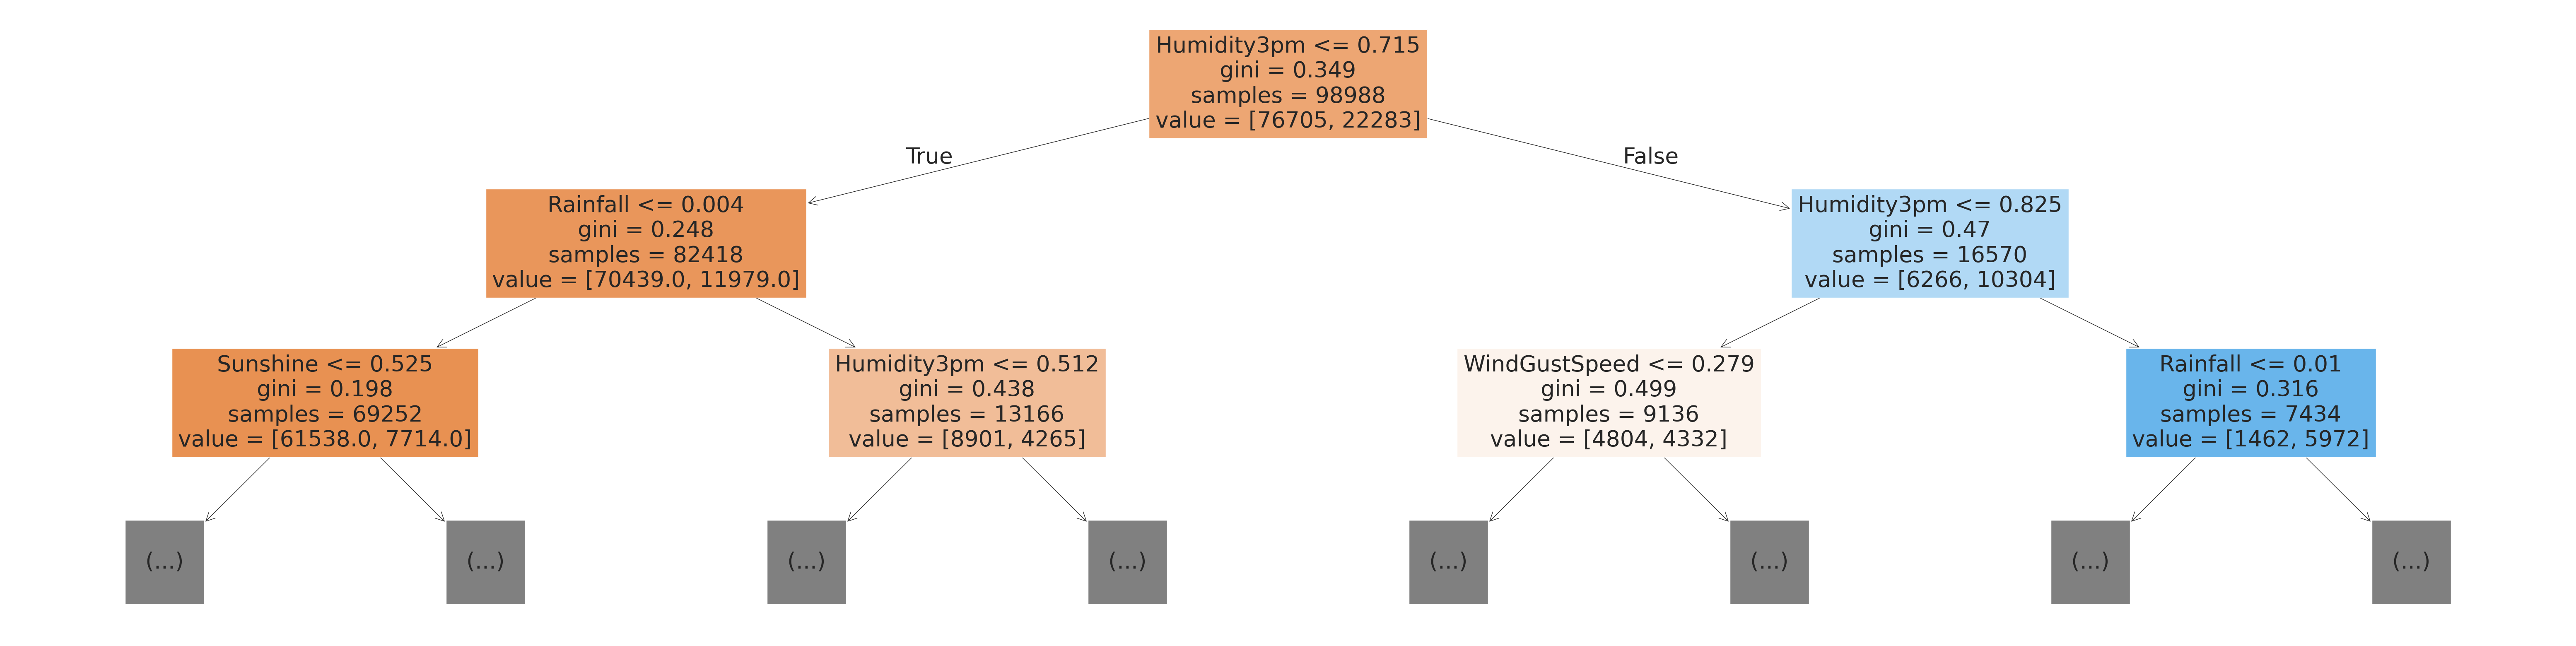

In [38]:
plt.figure(figsize = (80, 20))
plot_tree(model, feature_names = X_train.columns, max_depth = 2, filled = True)

**How a Decision Tree is Created**

Note the `gini` value in each box. This is a loss function used by the decision tree to decide whih column should be used for splitting the data, and at what point tht column should be split. A lower Gini Index indicates a better split. A perfict split (only one class on each side) has a Gini index of 0.

In [39]:
# Depth of the tree we have created
model.tree_.max_depth

48

We can also display the tree as textm which can be easier to follow

In [40]:
tree_text = export_text(model, max_depth = 10, feature_names = list(X_train.columns))
print(tree_text[:5000])

|--- Humidity3pm <= 0.72
|   |--- Rainfall <= 0.00
|   |   |--- Sunshine <= 0.52
|   |   |   |--- Pressure3pm <= 0.58
|   |   |   |   |--- WindGustSpeed <= 0.36
|   |   |   |   |   |--- Humidity3pm <= 0.28
|   |   |   |   |   |   |--- WindDir9am_NE <= 0.50
|   |   |   |   |   |   |   |--- Location_Watsonia <= 0.50
|   |   |   |   |   |   |   |   |--- Cloud9am <= 0.83
|   |   |   |   |   |   |   |   |   |--- WindSpeed3pm <= 0.07
|   |   |   |   |   |   |   |   |   |   |--- Pressure3pm <= 0.46
|   |   |   |   |   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |   |   |   |   |--- Pressure3pm >  0.46
|   |   |   |   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |   |   |   |--- WindSpeed3pm >  0.07
|   |   |   |   |   |   |   |   |   |   |--- MinTemp <= 0.32
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |   |--- MinTemp >  0.32
|   |   |   |   |   |   |   |   |   |   |   |--- truncated

### Feature Importance

Based on the gini index computations, a decision tree assigns an "importance" value to each feature. These values can be used to interpret the results given by a decision tree.

In [41]:
model.feature_importances_

array([0.03450243, 0.0326979 , 0.0588707 , 0.02398851, 0.04973483,
       0.05536477, 0.02888049, 0.02916332, 0.03948956, 0.26258596,
       0.03464976, 0.06252979, 0.01335156, 0.01832233, 0.03344341,
       0.03103312, 0.00229202, 0.00242598, 0.00137905, 0.00072507,
       0.00153394, 0.00118986, 0.00076956, 0.0015545 , 0.00107346,
       0.00141115, 0.00107036, 0.00196324, 0.00181935, 0.00034969,
       0.00100552, 0.00155723, 0.00046338, 0.00101511, 0.00169162,
       0.00084242, 0.00105612, 0.00086093, 0.00168535, 0.00187041,
       0.00051907, 0.00047732, 0.00149774, 0.00154991, 0.00137383,
       0.00122996, 0.00074085, 0.00140641, 0.0010652 , 0.0021117 ,
       0.00070719, 0.00175523, 0.00097529, 0.00137448, 0.00116001,
       0.00042945, 0.00151262, 0.00034984, 0.00081469, 0.00148406,
       0.00152123, 0.00148832, 0.00265512, 0.0019318 , 0.00033358,
       0.0014037 , 0.00150786, 0.00207691, 0.00347399, 0.00252085,
       0.00225861, 0.00221304, 0.00333089, 0.00219937, 0.00302

Let's turn this into dataframe and visualize the most important features

In [42]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending = False)

In [43]:
importance_df.head(10)

,feature,importance
9,Humidity3pm,0.262586
11,Pressure3pm,0.062530
2,Rainfall,0.058871
5,WindGustSpeed,0.055365
4,Sunshine,0.049735
8,Humidity9am,0.039490
10,Pressure9am,0.034650
0,MinTemp,0.034502
14,Temp9am,0.033443
1,MaxTemp,0.032698


<Axes: title={'center': 'Feature Importance'}, xlabel='importance', ylabel='feature'>

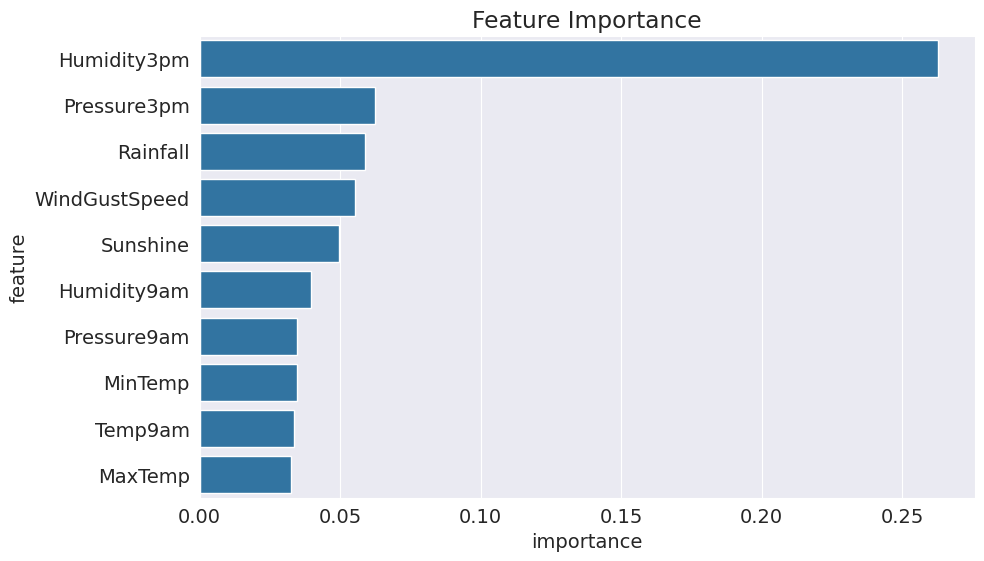

In [44]:
plt.title('Feature Importance')
sns.barplot(data = importance_df.head(10), x = 'importance', y = 'feature')

We can see that humidity3pm is the most important feature, as shown in the decision tree diagram

## Hyperparameter Tuning and Overfitting

As we saw in the previous section, our decision tree classifier memorized all the training examples, leading to a 100% training accuracy, while validation accuracy was only marginally better than ad dumb baseline model. This phenomenon is called overfitting and in this sectionm we'll look at some strategies for reducing overfitting. The process of refucing overfitting is known as *regularization*

The `DecisionTreeClassifier` accepts several arguments, some of which can be modified to refuce overfitting.

In [45]:
#?DecisionTreeClassifier

We can find the other parameters that a Decision Tree can take using a "?" before the model

We will explore a couple of hyperparameters

* `max_depth`
* `max_leaf_nodes`

`max_depth`

By reducing the maximum depth of the decision tree, we can prevent the tree from memorizing all the training examples, which can lead to better generalization

In [46]:
model.tree_.max_depth

48

Let's go only 3 levels deep and see what happens

In [47]:
model = DecisionTreeClassifier(max_depth = 3, random_state = 42)

In [48]:
model.fit(X_train, train_targets)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [49]:
model.score(X_train, train_targets)

0.8291308037337859

In [50]:
model.score(X_val, val_targets)

0.8334397307178921

While the training accuracy has gone down, the validation accuracy of the model has increased

[Text(0.5, 0.875, 'Humidity3pm <= 0.715\ngini = 0.349\nsamples = 98988\nvalue = [76705, 22283]\nclass = No'),
 Text(0.25, 0.625, 'Rainfall <= 0.004\ngini = 0.248\nsamples = 82418\nvalue = [70439.0, 11979.0]\nclass = No'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Sunshine <= 0.525\ngini = 0.198\nsamples = 69252\nvalue = [61538.0, 7714.0]\nclass = No'),
 Text(0.0625, 0.125, 'gini = 0.363\nsamples = 12620\nvalue = [9618, 3002]\nclass = No'),
 Text(0.1875, 0.125, 'gini = 0.153\nsamples = 56632\nvalue = [51920, 4712]\nclass = No'),
 Text(0.375, 0.375, 'Humidity3pm <= 0.512\ngini = 0.438\nsamples = 13166\nvalue = [8901, 4265]\nclass = No'),
 Text(0.3125, 0.125, 'gini = 0.293\nsamples = 4299\nvalue = [3531, 768]\nclass = No'),
 Text(0.4375, 0.125, 'gini = 0.478\nsamples = 8867\nvalue = [5370, 3497]\nclass = No'),
 Text(0.75, 0.625, 'Humidity3pm <= 0.825\ngini = 0.47\nsamples = 16570\nvalue = [6266, 10304]\nclass = Yes'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'WindGustSp

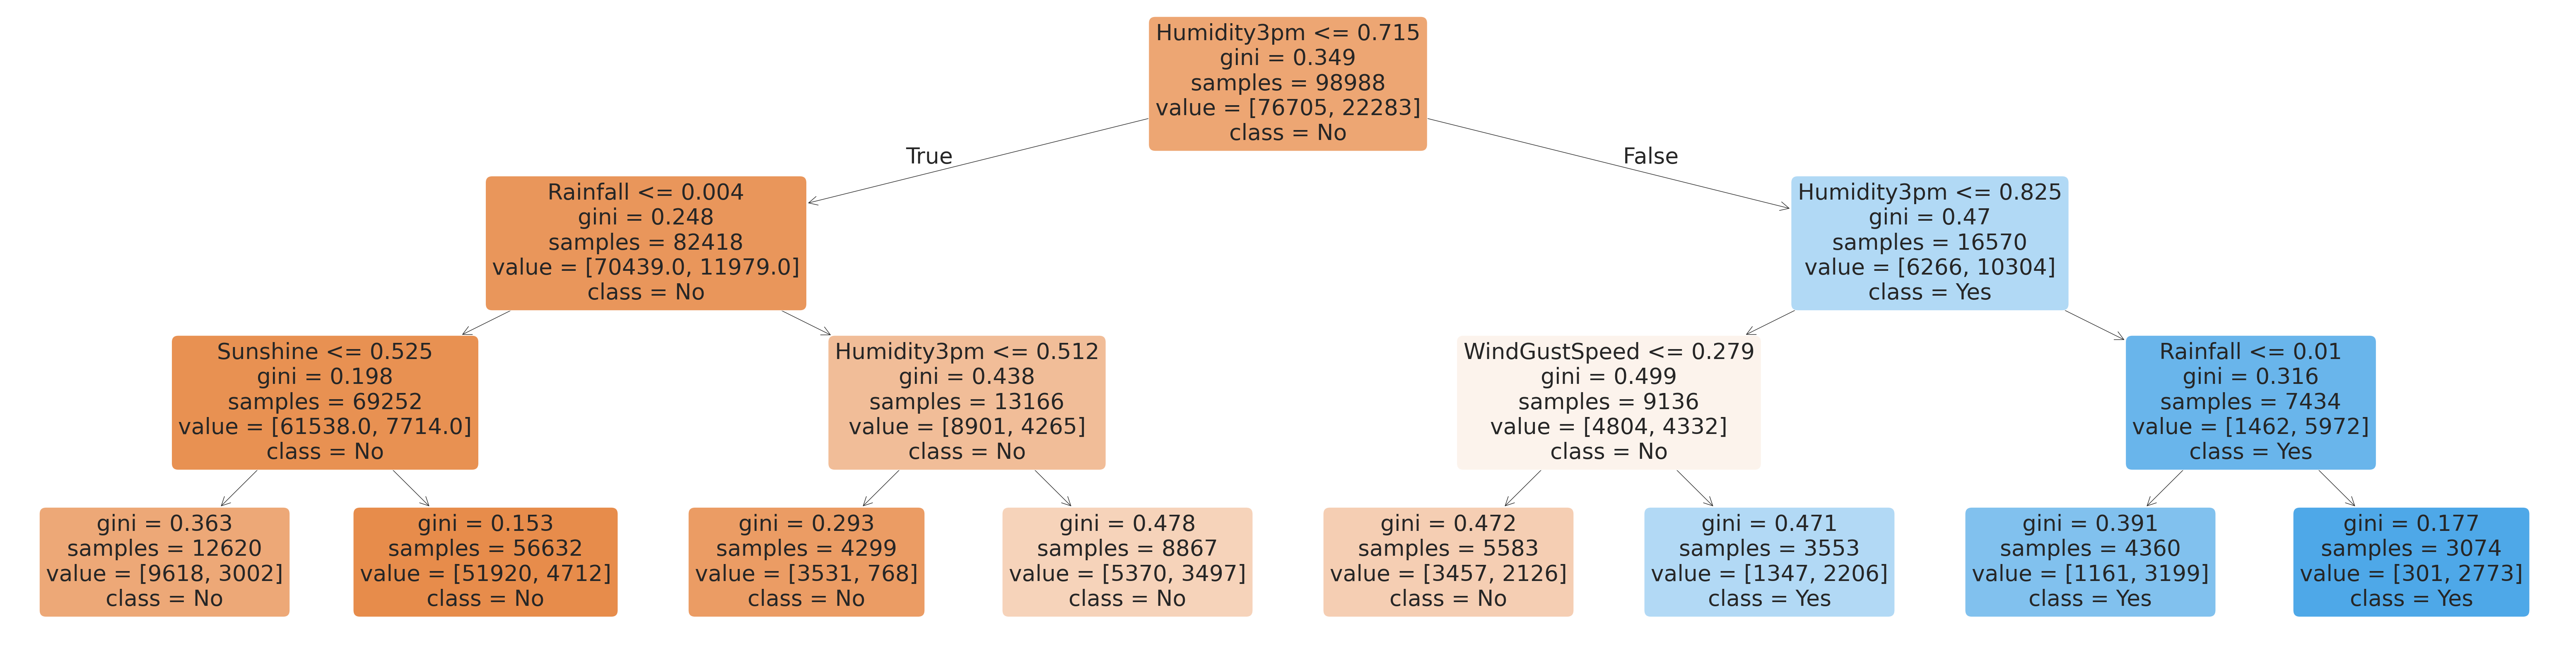

In [51]:
plt.figure(figsize = (80, 20))
plot_tree(model, feature_names = X_train.columns, filled = True, rounded = True, class_names = model.classes_)

In [52]:
print(export_text(model, feature_names=list(X_train.columns)))

|--- Humidity3pm <= 0.72
|   |--- Rainfall <= 0.00
|   |   |--- Sunshine <= 0.52
|   |   |   |--- class: No
|   |   |--- Sunshine >  0.52
|   |   |   |--- class: No
|   |--- Rainfall >  0.00
|   |   |--- Humidity3pm <= 0.51
|   |   |   |--- class: No
|   |   |--- Humidity3pm >  0.51
|   |   |   |--- class: No
|--- Humidity3pm >  0.72
|   |--- Humidity3pm <= 0.82
|   |   |--- WindGustSpeed <= 0.28
|   |   |   |--- class: No
|   |   |--- WindGustSpeed >  0.28
|   |   |   |--- class: Yes
|   |--- Humidity3pm >  0.82
|   |   |--- Rainfall <= 0.01
|   |   |   |--- class: Yes
|   |   |--- Rainfall >  0.01
|   |   |   |--- class: Yes



Let's experiment with differnt depths using helper function

In [53]:
def max_depth_error(md):
  model = DecisionTreeClassifier(max_depth = md, random_state = 42)
  model.fit(X_train, train_targets)
  train_error = 1 - model.score(X_train, train_targets)
  val_error = 1 - model.score(X_val, val_targets)
  return {
      'Max Depth': md,
      'Training Error': train_error,
      'Validation Error': val_error
  }

In [54]:
%%time
errors_df = pd.DataFrame([max_depth_error(md) for md in range(1, 21)])

CPU times: user 47.4 s, sys: 1.5 s, total: 48.9 s
Wall time: 54 s


In [55]:
errors_df

,Max Depth,Training Error,Validation Error
0,1,0.184315,0.177935
1,2,0.179547,0.172712
2,3,0.170869,0.166560
3,4,0.165707,0.164355
4,5,0.160676,0.159074
5,6,0.156211,0.157275
6,7,0.153231,0.154721
7,8,0.147644,0.157797
8,9,0.140724,0.156346
9,10,0.132703,0.158319


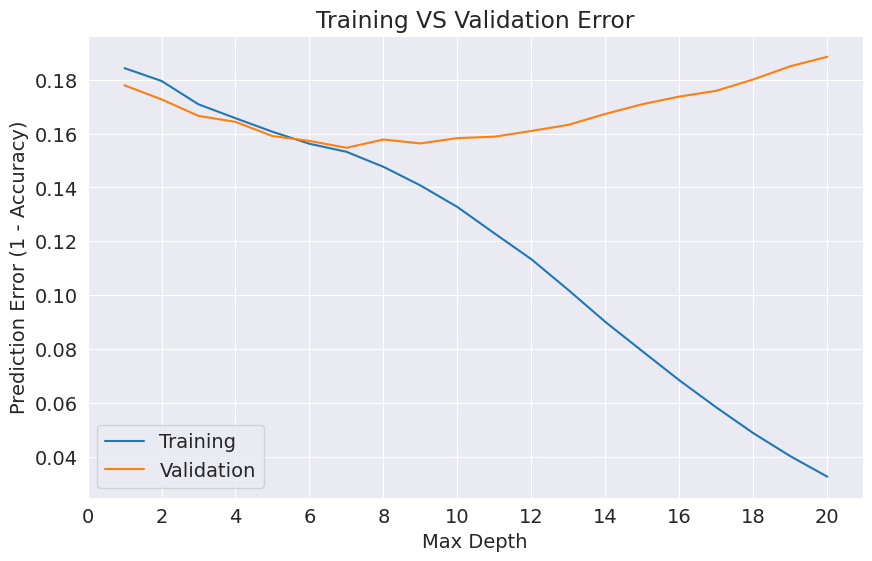

In [56]:
plt.figure()
plt.plot(errors_df['Max Depth'], errors_df['Training Error'])
plt.plot(errors_df['Max Depth'], errors_df['Validation Error'])
plt.title('Training VS Validation Error')
plt.xticks(range(0, 21, 2))
plt.xlabel('Max Depth')
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.legend(['Training', 'Validation'])

As we can see in the above plot, the model is performing best around 7 depths, the decision tree is at its best. After that the model is overfitting, memorizing the training data.

In [57]:
model = DecisionTreeClassifier(max_depth = 7, random_state = 42).fit(X_train, train_targets)
model.score(X_train, train_targets), model.score(X_val, val_targets)

(0.8467693053703479, 0.8452788578724392)

We looked at one hyperparameter, max_depth, and our model increased by leaps and bounds. Now lets see another hyperparameter

`max_leaf_nodes`

Another way to control the size of complexity of a decision tree is to limit the number of leaf nodes. This allows branches of the tree to have varying depths

In [58]:
model = DecisionTreeClassifier(max_leaf_nodes = 128, random_state = 42).fit(X_train, train_targets)

In [59]:
model.score(X_train, train_targets), model.score(X_val, val_targets)

(0.8480421869317493, 0.8442342290058615)

In [60]:
model.tree_.max_depth

12

In [61]:
model_text = export_text(model, feature_names = list(X_train.columns))
print(model_text[:2000])

|--- Humidity3pm <= 0.72
|   |--- Rainfall <= 0.00
|   |   |--- Sunshine <= 0.52
|   |   |   |--- Pressure3pm <= 0.58
|   |   |   |   |--- WindGustSpeed <= 0.36
|   |   |   |   |   |--- Humidity3pm <= 0.28
|   |   |   |   |   |   |--- class: No
|   |   |   |   |   |--- Humidity3pm >  0.28
|   |   |   |   |   |   |--- Sunshine <= 0.05
|   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |--- Sunshine >  0.05
|   |   |   |   |   |   |   |--- Pressure3pm <= 0.43
|   |   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |   |--- Pressure3pm >  0.43
|   |   |   |   |   |   |   |   |--- Humidity3pm <= 0.57
|   |   |   |   |   |   |   |   |   |--- WindDir9am_NE <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- WindDir9am_NNE <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |   |   |   |   |--- WindDir9am_NNE >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |   |   |   |--- WindD

## Training a Random Forest

While tuning a hyperparameters of a single decision tree may lead to some improvements, a much more effective strategy is to combine the results of several decision trees that have been trained with slightly different parameters. This is called a `random forest model`

The idea is that each decision tree in the forest will make different kind of errors, and upon averaging, many of their errors will cancel out. This idea is also commonly knows as the "wisdom of the crowd".

In [62]:
model = RandomForestClassifier(n_jobs = -1, random_state = 42)

`n_jobs` allows the random forest to use multiple parallel workers to train decision trees and random_state = 42 ensures that we get the same results

In [63]:
%%time
model.fit(X_train, train_targets)

CPU times: user 42.8 s, sys: 328 ms, total: 43.1 s
Wall time: 32.4 s


RandomForestClassifier(n_jobs=-1, random_state=42)

In [64]:
model.score(X_train, train_targets), model.score(X_val, val_targets)

(0.9999595910615429, 0.8553769369160235)

It makes sense that the training accuracy is almost 100% as we did not put any limitation on the model what so ever, so it is basically memorizing the training data.
But if you notice, the validation accuracy is far better than before

The general technique of combining results of many models is called "ensembling". It works because most errors of individual models cancel out on avearging.

In [65]:
train_probs = model.predict_proba(X_train)
train_probs

array([[0.92, 0.08],
       [0.99, 0.01],
       [1.  , 0.  ],
       ...,
       [0.99, 0.01],
       [1.  , 0.  ],
       [0.93, 0.07]])

In [66]:
# We have 100 decision trees
len(model.estimators_)

100

We can access individual tree using `model.estimators`.

Let's plot decision tree number 0 and 20

[Text(0.5, 0.875, 'Sunshine <= 0.403\ngini = 0.347\nsamples = 62607\nvalue = [76887, 22101]'),
 Text(0.25, 0.625, 'Pressure9am <= 0.609\ngini = 0.499\nsamples = 11288\nvalue = [9272, 8542]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Cloud9am <= 0.833\ngini = 0.475\nsamples = 6067\nvalue = [3702, 5808]'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'Pressure9am <= 0.718\ngini = 0.442\nsamples = 5221\nvalue = [5570.0, 2734.0]'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'Rainfall <= 0.003\ngini = 0.278\nsamples = 51319\nvalue = [67615, 13559]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'WindDir9am_E <= 0.5\ngini = 0.201\nsamples = 41418\nvalue = [58053, 7422]'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'WindGustSpeed <= 0.349\ngini = 0.476\nsamples = 9901\nvalue = [9562, 6137]'),
 Text(0.8125, 0.125, '\n 

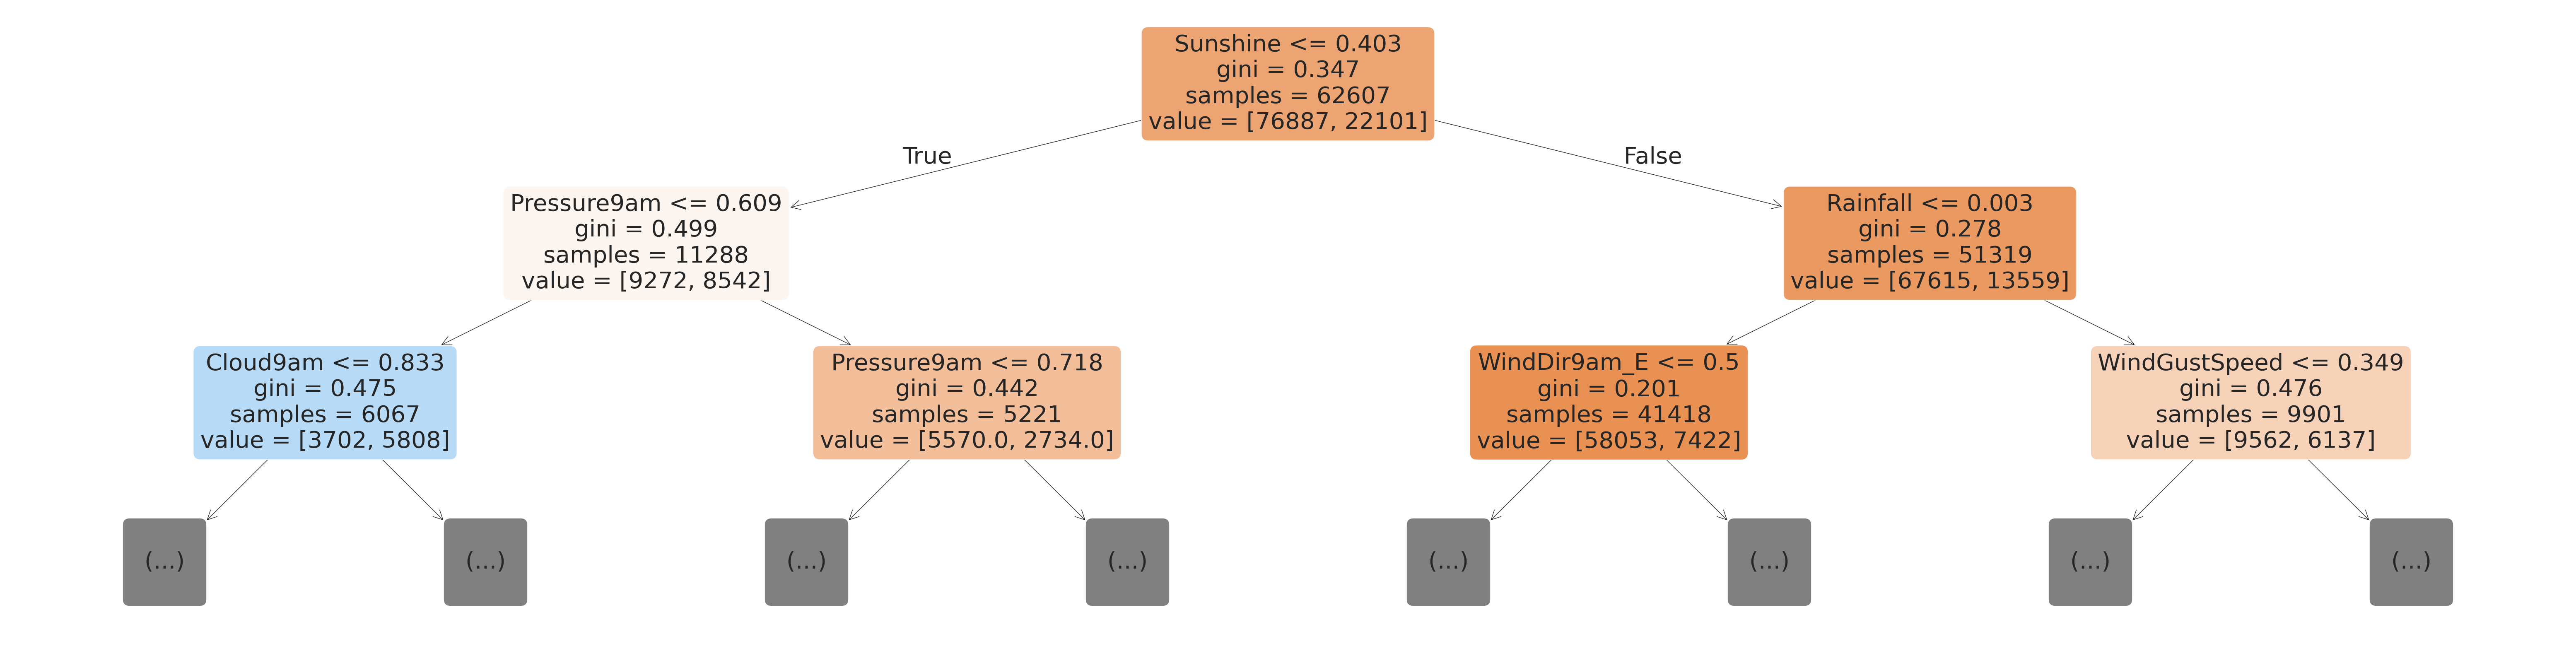

In [67]:
plt.figure(figsize = (80, 20))
plot_tree(model.estimators_[0], max_depth = 2, feature_names = X_train.columns, filled = True, rounded = True)

[Text(0.5, 0.875, 'Sunshine <= 0.417\ngini = 0.349\nsamples = 62448\nvalue = [76707, 22281]'),
 Text(0.25, 0.625, 'Humidity3pm <= 0.745\ngini = 0.499\nsamples = 11821\nvalue = [9860, 8914]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'WindSpeed9am <= 0.15\ngini = 0.45\nsamples = 7988\nvalue = [8315, 4320]'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'WindSpeed9am <= 0.062\ngini = 0.377\nsamples = 3833\nvalue = [1545, 4594]'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'Humidity3pm <= 0.745\ngini = 0.278\nsamples = 50627\nvalue = [66847, 13367]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Cloud3pm <= 0.278\ngini = 0.216\nsamples = 45991\nvalue = [63920, 8957]'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'Location_NorahHead <= 0.5\ngini = 0.48\nsamples = 4636\nvalue = [2927, 4410]'),
 Text(0.8125, 0.125, '\

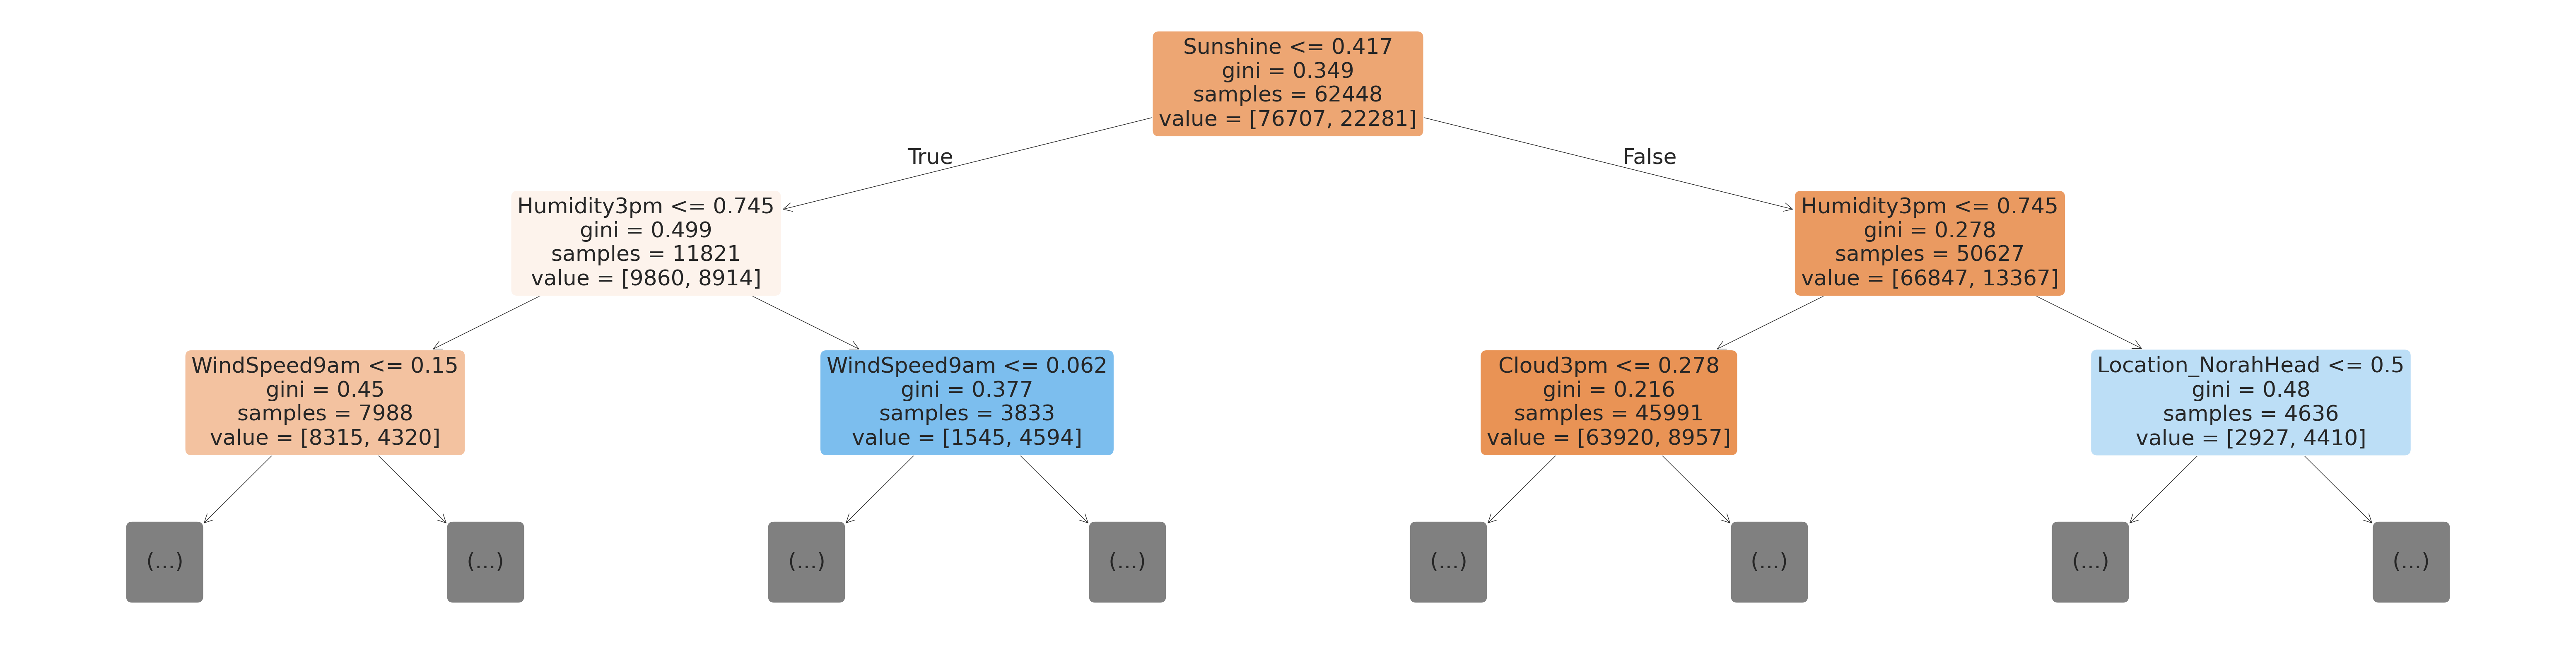

In [68]:
plt.figure(figsize = (80, 20))
plot_tree(model.estimators_[15], max_depth = 2, feature_names = X_train.columns, filled = True, rounded = True)

In [69]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending = False)

In [70]:
importance_df.head(10)

,feature,importance
9,Humidity3pm,0.139391
4,Sunshine,0.055504
11,Pressure3pm,0.054219
8,Humidity9am,0.050754
10,Pressure9am,0.048210
5,WindGustSpeed,0.047833
2,Rainfall,0.047278
15,Temp3pm,0.045182
1,MaxTemp,0.041811
0,MinTemp,0.041537


<Axes: title={'center': 'Feature Importance'}, xlabel='importance', ylabel='feature'>

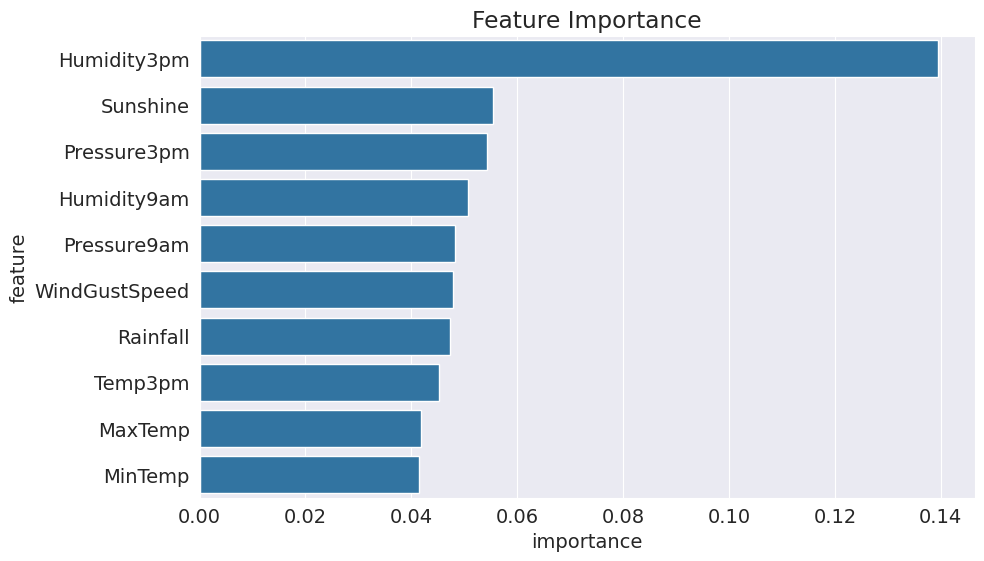

In [71]:
plt.title('Feature Importance')
sns.barplot(data = importance_df.head(10), x = 'importance', y = 'feature')

The distribution is less skewed than that of a single decision tree

## Hyperparameter Tuning with Random Forests

Just like decision trees, random forests also have several hyperparameters. In fact many of these hyperparameters are applied to the underlying decision trees.

Let's create a base model which we can compare to the fine tuned model

In [72]:
base_model = RandomForestClassifier(n_jobs = -1, random_state = 42).fit(X_train, train_targets)

In [73]:
base_train_acc = base_model.score(X_train, train_targets)
base_val_acc = base_model.score(X_val, val_targets)

In [75]:
base_accs = base_train_acc, base_val_acc
base_accs

(0.9999595910615429, 0.8553769369160235)

We can now use this benchmark for hyperparameter tuning

`n_estimators`

This argument controls the number of decision trees in the random forest. The default value is 100. For larger datasets, it helps to have a greater number of estimators. Start with fewer estimators as needed.
**10 estimators**

In [78]:
model = RandomForestClassifier(n_jobs = -1, n_estimators = 10, random_state = 42).fit(X_train, train_targets)

In [79]:
model.score(X_train, train_targets), model.score(X_val, val_targets)

(0.9872105709783005, 0.8467297312982416)

**500 estimators**

In [80]:
#model = RandomForestClassifier(n_jobs = -1, n_estimators = 500, random_state = 42).fit(X_train, train_targets)

In [81]:
#model.score(X_train, train_targets)

0.9999797955307714

In [82]:
#model.score(X_val, val_targets)

0.8566537055307295

In [83]:
base_accs

(0.9999595910615429, 0.8553769369160235)

The 500 estimators didn't do much for us, so we have to look out for this time to profit ration

`max_depth` and `max_leaf_nodes`

**n_estimators** do not bring any complexity to the model but just introduces more trees which changes the randomness, unlike max_depth and max_leaf_nodes.

These arguments are passed directly to each decision tree and control the maximum depth and the number of leafs of each tree respectilvely.

By defalut, no maximum depth is specified, which is why each tree has a training accuracy of 100%. You can specify a `max_depth` to reduce overfitting.

Let's define a helper function `test_params` to make it easy to test hyperparameters

In [88]:
def test_params(**params):
  model = RandomForestClassifier(n_jobs = -1, **params, random_state = 42).fit(X_train, train_targets)
  return model.score(X_train, train_targets), model.score(X_val, val_targets)

Let's test a few values of `max_depth` and `max_leaf_nodes`.

In [89]:
test_params(max_depth = 5)

(0.8209681981654342, 0.8250826997852707)

In [90]:
test_params(max_depth = 26)

(0.9816543419404372, 0.8567697754047937)

In [91]:
test_params(max_leaf_nodes = 2**5)

(0.8303127651836586, 0.8323370669142824)

In [92]:
test_params(max_leaf_nodes = 2**20)

(0.9999595910615429, 0.8572920898380825)

In [93]:
base_accs

(0.9999595910615429, 0.8553769369160235)

Max depth of 26 gave us the best result so far

`max_features`

Instead of picking all features (columns) for every split, we can specify that only a fraction to be choosen randomly to figure out a split.

**max_features : *{“auto”, “sqrt”, “log2”}, int or float, default="auto***

The number of features to consider when looking for the best split:
* If int, then consider `max_features` features at each split.
* If float, then `max_features` is a fraction and `round(max_features * n_features)` features are considered at each split.
* If "auto", then `max_features=sqrt(n_features)`.
* If "sqrt", then `max_features=sqrt(n_features)` (same as “auto")
* If "log2", then `max_features=log2(n_features)`.
* If None, then `max_features=n_features`.

Note: the search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than max_features features.

Notice that the default value auto causes only **√n** out of total features (n) to be chosen randomly at each split. This is the reason each decision tree in the forest is different. While it may seem counterintuitive, choosing all features for every split of every tree will lead to identical trees, so the random forest will not generalize well

In [95]:
test_params(max_features = 'log2')

(0.9999494888269285, 0.8540421333642852)

In [96]:
test_params(max_features = 3)

(0.9999393865923142, 0.8527653647495792)

In [100]:
test_params(max_features = 6)

(0.9999494888269285, 0.8540421333642852)

In [101]:
base_accs

(0.9999595910615429, 0.8553769369160235)

`min_samples_split` and `min_samples_leaf`

By default tree classifier tries to split every node that has 2 or more data inside it, splitting the data similarly as train_test_split.

In [105]:
test_params(min_samples_split = 5, min_samples_leaf = 2)

(0.9570756051238534, 0.8562474609715048)

In [103]:
test_params(min_samples_split = 100, min_samples_leaf = 60)

(0.8489311835778074, 0.8448145783761825)

In [104]:
base_accs

(0.9999595910615429, 0.8553769369160235)

`min_impurity_decrease`

This argument is used to control the threshold for splitting nodes. A node will be split if this split induces a decrease of the impurity (Gini index) greater than or equal to this value. It's default value is 0, and you increase it to reduce overfitting.

In [111]:
test_params(min_impurity_decrease = 1e-6)

(0.9885541681820018, 0.8560153212233764)

In [107]:
test_params(min_impurity_decrease = 1e-2)

(0.774891906089627, 0.7882885497069235)

In [108]:
base_accs

(0.9999595910615429, 0.8553769369160235)

`bootstrap`, `max_samples`

By default, a random forest does not use the entire dataset for training each decision tree. Instead it applies a technique called bootstrapping. For each tree, rows from the dataset are picked one by one randomly, with replacement i.e some rows may not show up at all, while some rows may show up multiple ties.

**bootstrap: *bool, default = True***

  Whether bootstrap samples are used when building trees. If False, the whole dataset is used to build each tree.

Bootstrapping helps the random forest generalize better, because each decision tree only sees a fraction of the training set, and some rows randomly get higher weightage than others.

In [112]:
test_params(bootstrap = False)

(0.9999797955307714, 0.8586268933898207)

In [113]:
base_accs

(0.9999595910615429, 0.8553769369160235)

When bootstrapping is enabled, you can control the number or fraction of rows to be considered for each bootstrap using `max_samples`.

**max_samples: *int or float, default = None***
If bootstrap is True, the number of samples to draw from X to train each base estimator

* If None (default), then draw `X.shape[0]` samples.
* if int, then draw `max_samples` samples.
* if float, then draw `max_samples * X.shape[0]` samples. Thus, `max_samples` should be in the interval `[0, 1]`

In [114]:
test_params(max_samples = 0.9)

(0.9997575463692568, 0.8560153212233764)

In [115]:
base_accs

(0.9999595910615429, 0.8553769369160235)

`class_weight`

In [116]:
model.classes_

array(['No', 'Yes'], dtype=object)

In [117]:
test_params(class_weight = 'balanced')

(0.9999595910615429, 0.8552608670419592)

In [118]:
test_params(class_weight = {'No': 1, 'Yes': 2})

(0.9999393865923142, 0.8554349718530555)

In [119]:
base_accs

(0.9999595910615429, 0.8553769369160235)

### Putting it together

Let's train a random forest with customized hyperparameters based on our learnings. Of course, different hyperparameters

In [123]:
model = RandomForestClassifier(n_jobs = -1,
                               random_state = 42,
                               n_estimators = 500,
                               max_features = 20,
                               max_depth = 30,
                               class_weight = {'No': 1, 'Yes': 1.5})

In [124]:
model.fit(X_train, train_targets)

RandomForestClassifier(class_weight={'No': 1, 'Yes': 1.5}, max_depth=30,
                       max_features=20, n_estimators=500, n_jobs=-1,
                       random_state=42)

In [125]:
model.score(X_train, train_targets), model.score(X_val, val_targets)

(0.9990503899462561, 0.857582264523243)

We've increased the accuracy from 84.5% with a single decision tree to 85.7% with a well-tuned random forest. Depending on the dataset and the kind of problem, you may or may not a see a significant improvement with hyperparameter tuning.
This could be due to any of the following reasons:

* We may not have found the right mix of hyperparameters to regularize (reduce overfitting) the model properly, and we should keep trying to improve the model.

* We may have reached the limits of the modeling technique we're currently using (Random Forests), and we should try another modeling technique e.g. gradient boosting.

* We may have reached the limits of what we can predict using the given amount of data, and we may need more data to improve the model.

* We may have reached the limits of how well we can predict whether it will rain tomorrow using the given weather measurements, and we may need more features (columns) to further improve the model. In many cases, we can also
generate new features using existing features (this is called feature engineering),

* Whether it will rain tomorrow may be an inherently random or chaotic phenomenon which simply cannot be predicted beyond a certain accuracy any amount of data for any number of weather measurements with any modeling

Remmeber that ultimately all models are wrong, but some are useful. If you can rely on the model we've created today to make a travel decision for tomorrow, then the model is useful, even though it may be sometimes be wrong

In [126]:
raw_df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,2017-06-20,Uluru,3.5,21.8,0.0,NaN,NaN,E,31.0,ESE,E,15.0,13.0,59.0,27.0,1024.7,1021.2,NaN,NaN,9.4,20.9,No,No
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,ENE,13.0,11.0,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,N,13.0,9.0,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,WNW,9.0,9.0,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No


Let's compute the accuracy of our model on the test set

In [127]:
model.score(X_test, test_targets)

0.8455378455378455

## Making Predictions on New Inputs

In [131]:
def predict_input(model, single_input):
  input_df = pd.DataFrame([single_input])
  input_df[numeric_cols] = imputer.transform(input_df[numeric_cols])
  input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
  input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
  X_input = input_df[numeric_cols + encoded_cols]
  pred = model.predict(X_input)[0]
  prob = model.predict_proba(X_input)[0][list(model.classes_).index(pred)]
  return pred, prob

In [136]:
new_input = {
    'Date': '2021-06-19',
    'Location': 'Launceston',
    'MinTemp': 23.2,
    'MaxTemp': 33.2,
    'Rainfall': 10.2,
    'Evaporation': 4.2,
    'Sunshine': np.nan,
    'WindGustDir': 'NNW',
    'WindGustSpeed': 52.0,
    'WindDir9am': 'NW',
    'WindDir3pm': 'NNE',
    'WindSpeed9am': 13.0,
    'Humidity9am': 89.0,
    'WindSpeed3pm': 20.0,
    'Humidity3pm': 58.0,
    'Pressure9am': 1004.8,
    'Pressure3pm': 1001.5,
    'Cloud9am': 8.0,
    'Cloud3pm': 5.0,
    'Temp9am': 25.7,
    'Temp3pm': 33.0,
    'RainToday': 'Yes'}

In [137]:
predict_input(model, new_input)

/tmp/ipython-input-1105496283.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
/tmp/ipython-input-1105496283.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
/tmp/ipython-input-1105496283.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

('Yes', np.float64(0.7946368768821167))

## Saving and Loading the model

We can save the parameters(weights and biases) of our trained model to disk, so that we won't have to train the model again from scratch. Along with the model, it is important to save, imputers, scalers, encoders and even column names. Anything what will be required while generating predictions using the model should be saved.

We can use `joblib` module to save and load Python object on the disk.


In [139]:
aussie_rain = {
    'model': model,
    'imputer': imputer,
    'scaler': scaler,
    'encoder': encoder,
    'input_cols': input_cols,
    'target_cols': target_cols,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'encoded_cols': encoded_cols
}

In [140]:
joblib.dump(aussie_rain, 'aussie_rain.joblib')

['aussie_rain.joblib']

The object can be loaded using joblib.load

In [141]:
aussie_rain2 = joblib.load('aussie_rain.joblib')

In [142]:
test_preds2 = aussie_rain2['model'].predict(X_test)

In [144]:
accuracy_score(test_targets, test_preds2)

0.8455378455378455

## Summary

The following topics were covered in this tutorial

* Downloading a real world dataset
* Preparing a dataset for training
* Training and interpreting decision trees.
* Training and interpreting random forests.
* Overfitting, hyperparameters tuning and regularization.
* Making predictions on single inputs.

We also introduced the following terms.

* Decision Tree
* Random Forest
* Overfitting
* Hyperparameter
* Hyperparameter tuning
* Regularization
* Ensembling
* Generalization
* Bootstrapping